<a href="https://colab.research.google.com/github/simondiange/simondiange/blob/main/Heart_disease_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [136]:
# This URL points to a well-known repository for this dataset.
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

# The dataset at this URL does not have a header row and uses commas as separators.
# Also, it contains missing values represented by '?'.
# We need to provide column names and handle missing values during loading.
column_names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
df = pd.read_csv(url, names=column_names, na_values='?')

print("First 5 rows of the DataFrame:")
display(df.head())

print("\nInformation about the DataFrame:")
display(df.info())

First 5 rows of the DataFrame:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0



Information about the DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


None

## Perform EDA


Analyze the dataset to understand the distribution of features, identify potential outliers, and explore the relationships between features and the target variable (heart disease). This will involve creating visualizations and summarizing key statistics.


Display descriptive statistics for all columns in the DataFrame `df` to get a summary of central tendency, dispersion, and shape of the distributions.



In [119]:
print("Descriptive statistics for the DataFrame:")
display(df.describe())

Descriptive statistics for the DataFrame:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


Generate histograms for all numerical features to visualize their distributions and identify potential skewness or outliers.



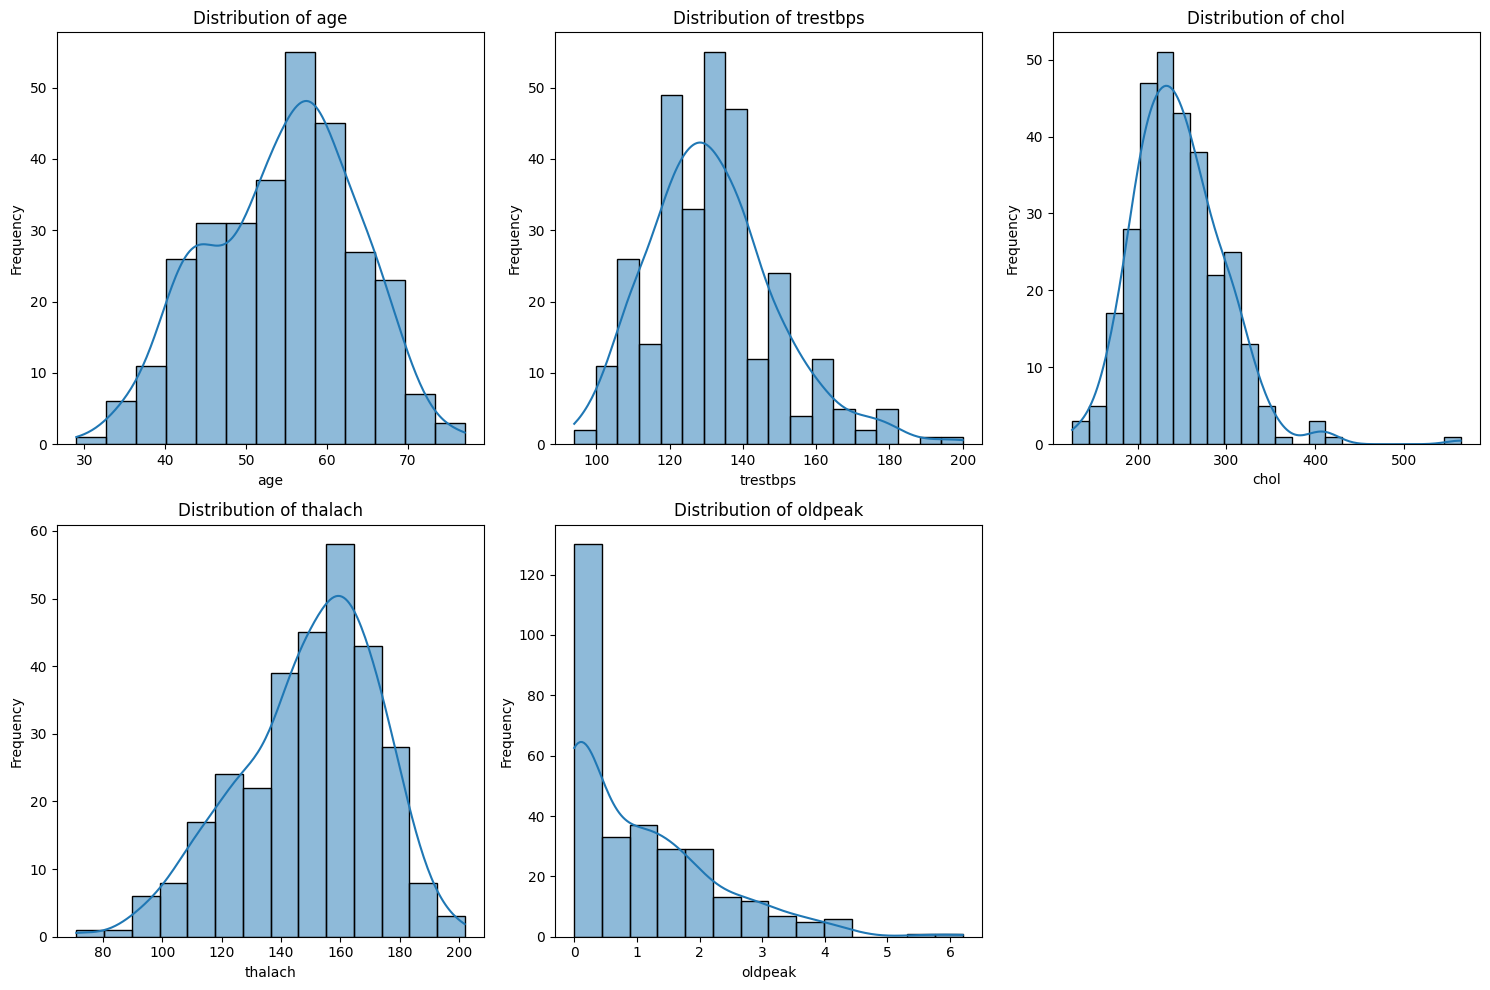

In [120]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns (excluding the target variable which is categorical for this analysis)
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# Determine the number of rows and columns for the subplot grid
n_cols = 3
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols

# Create histograms for numerical features
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 5))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, col in enumerate(numerical_cols):
    sns.histplot(data=df, x=col, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Create count plots for categorical features to understand the distribution of categories.



/tmp/ipython-input-974340503.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette='viridis', order=sorted(df[col].dropna().unique()))
/tmp/ipython-input-974340503.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette='viridis', order=sorted(df[col].dropna().unique()))
/tmp/ipython-input-974340503.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette='viridis', order=sorted(df[col].dropna().unique()))
/tmp/ipython-input-974340503.py

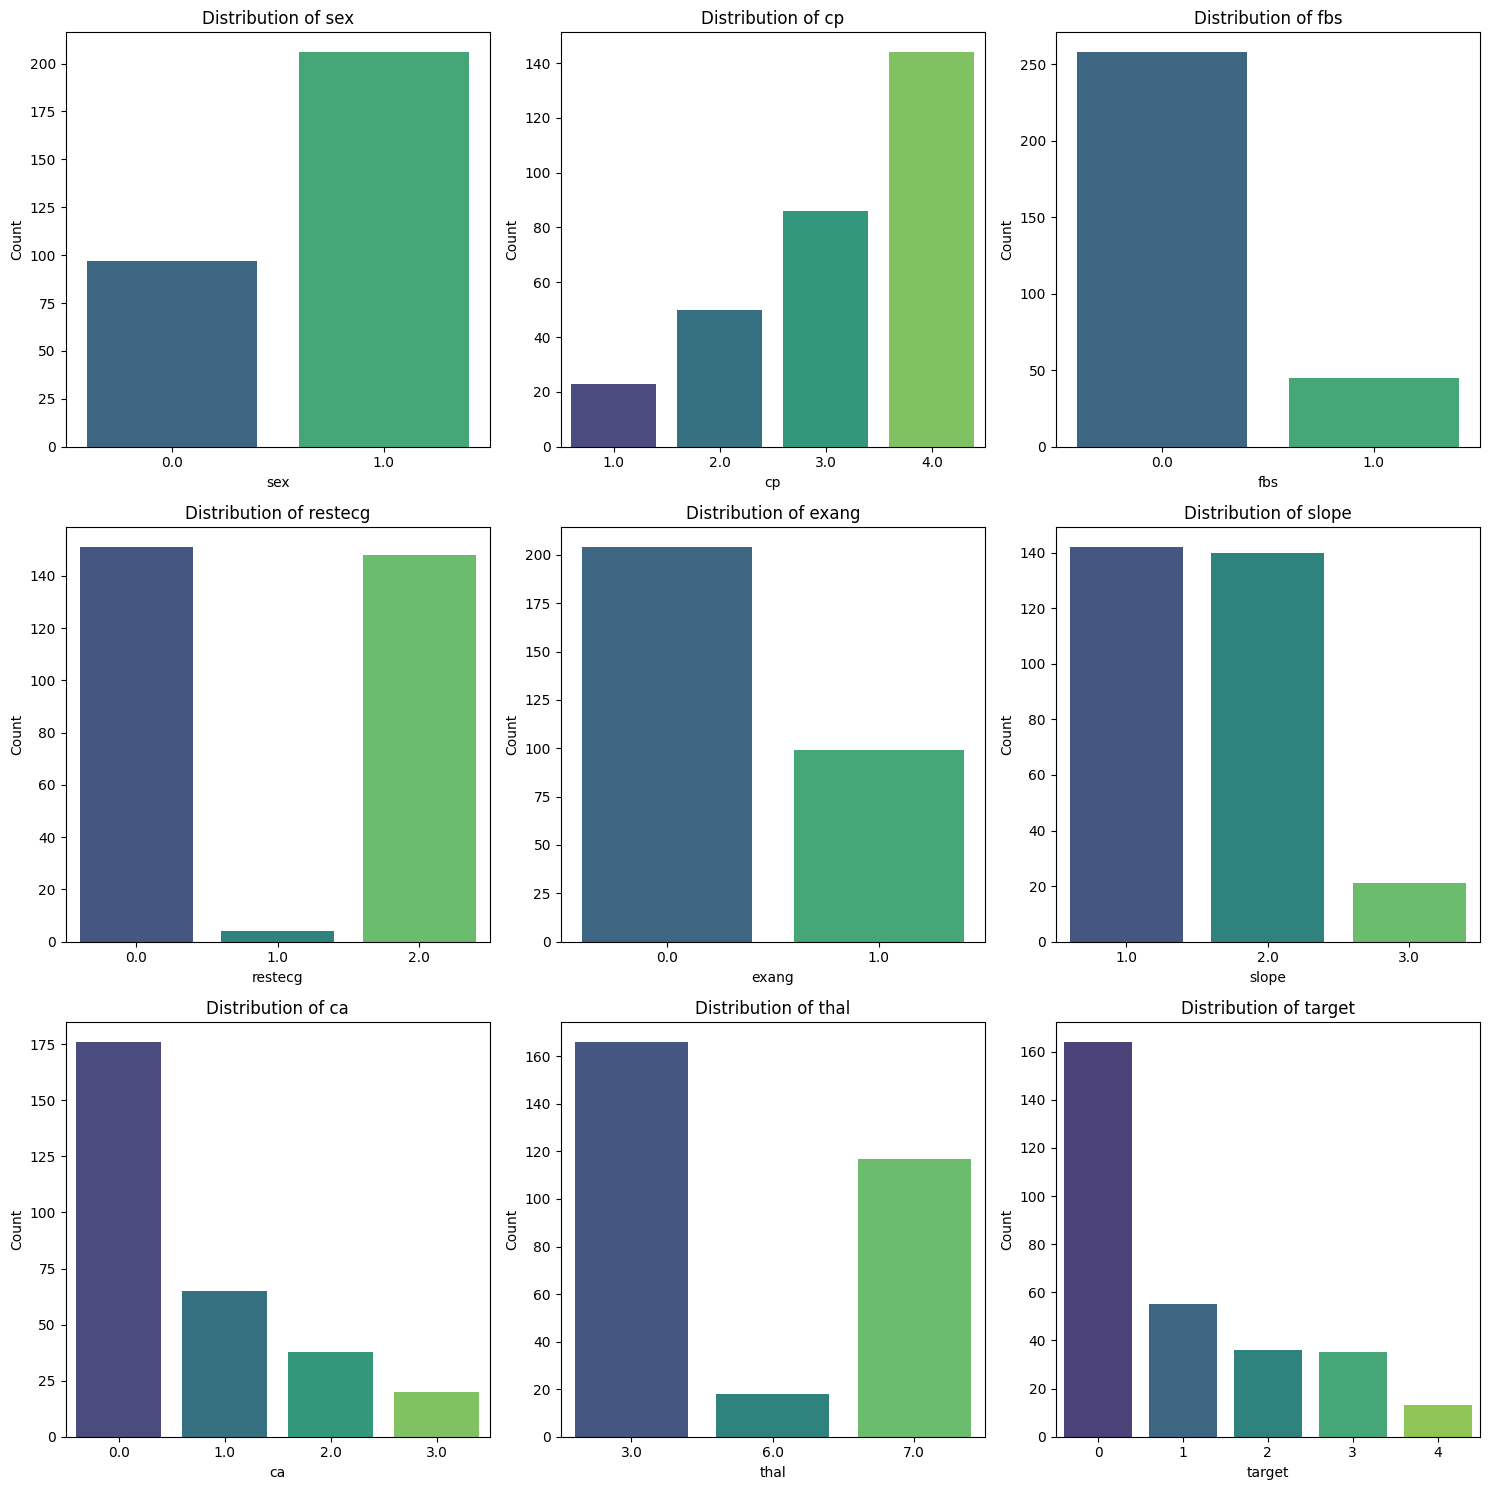

In [121]:
# Select categorical columns (including the target variable for now)
# Based on the data description, the following columns are categorical:
# sex, cp, fbs, restecg, exang, slope, ca, thal, target
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'target']

# Determine the number of rows and columns for the subplot grid
n_cols = 3
n_rows = (len(categorical_cols) + n_cols - 1) // n_cols

# Create count plots for categorical features
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 5))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, col in enumerate(categorical_cols):
    # Handle potential NaN values in categorical columns by adding them to the plot
    sns.countplot(data=df, x=col, ax=axes[i], palette='viridis', order=sorted(df[col].dropna().unique()))
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Calculate and display the correlation matrix for the numerical features to understand the relationships between them.



Correlation Matrix of Numerical Features:


,age,trestbps,chol,thalach,oldpeak
age,1.000000,0.284946,0.208950,-0.393806,0.203805
trestbps,0.284946,1.000000,0.130120,-0.045351,0.189171
chol,0.208950,0.130120,1.000000,-0.003432,0.046564
thalach,-0.393806,-0.045351,-0.003432,1.000000,-0.343085
oldpeak,0.203805,0.189171,0.046564,-0.343085,1.000000


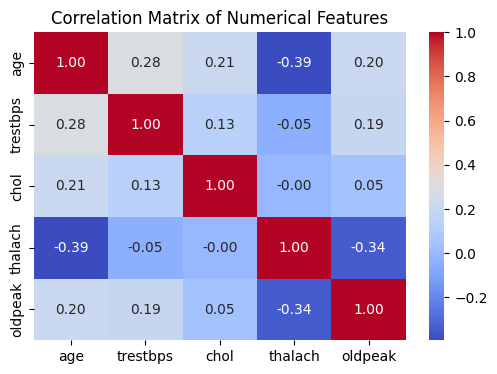

In [122]:
# Calculate the correlation matrix for numerical features
correlation_matrix = df[numerical_cols].corr()

print("Correlation Matrix of Numerical Features:")
display(correlation_matrix)

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

Generate box plots for numerical features, grouped by the 'target' variable, to explore how the distribution of each numerical feature differs between patients with and without heart disease.



/tmp/ipython-input-2104985923.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='target', y=col, ax=axes[i], palette='viridis')
/tmp/ipython-input-2104985923.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='target', y=col, ax=axes[i], palette='viridis')
/tmp/ipython-input-2104985923.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='target', y=col, ax=axes[i], palette='viridis')
/tmp/ipython-input-2104985923.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be rem

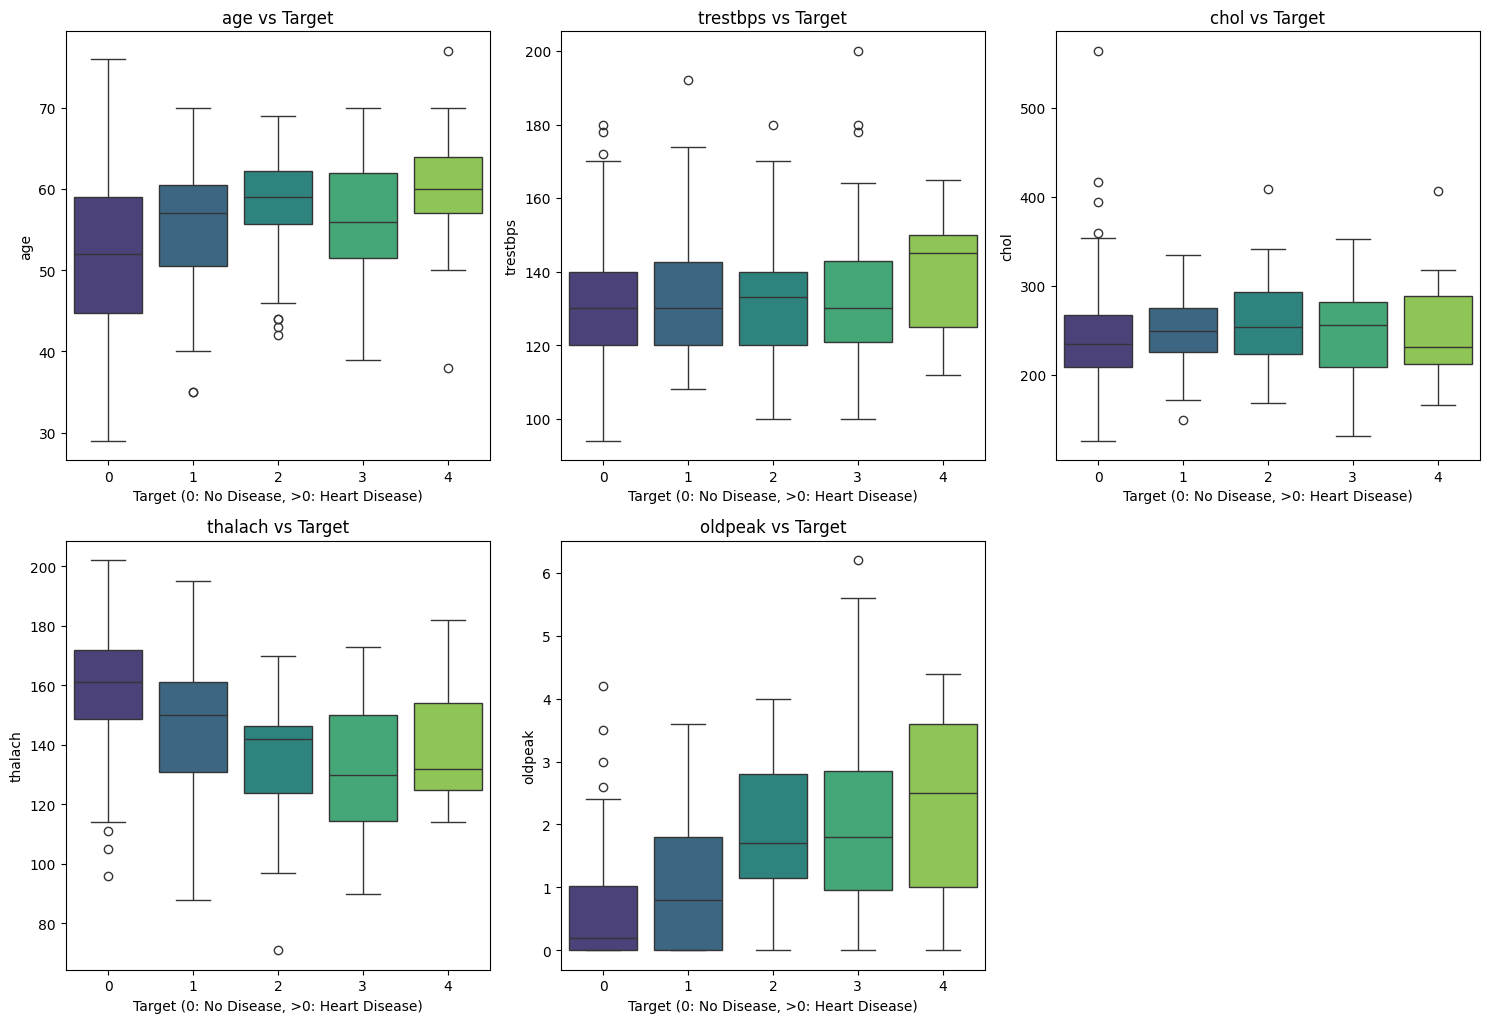

In [123]:
# Generate box plots for numerical features grouped by the target variable
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 5))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, col in enumerate(numerical_cols):
    sns.boxplot(data=df, x='target', y=col, ax=axes[i], palette='viridis')
    axes[i].set_title(f'{col} vs Target')
    axes[i].set_xlabel('Target (0: No Disease, >0: Heart Disease)')
    axes[i].set_ylabel(col)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Create count plots for categorical features, grouped by the 'target' variable, to understand how the distribution of categories within each categorical feature relates to the presence of heart disease.



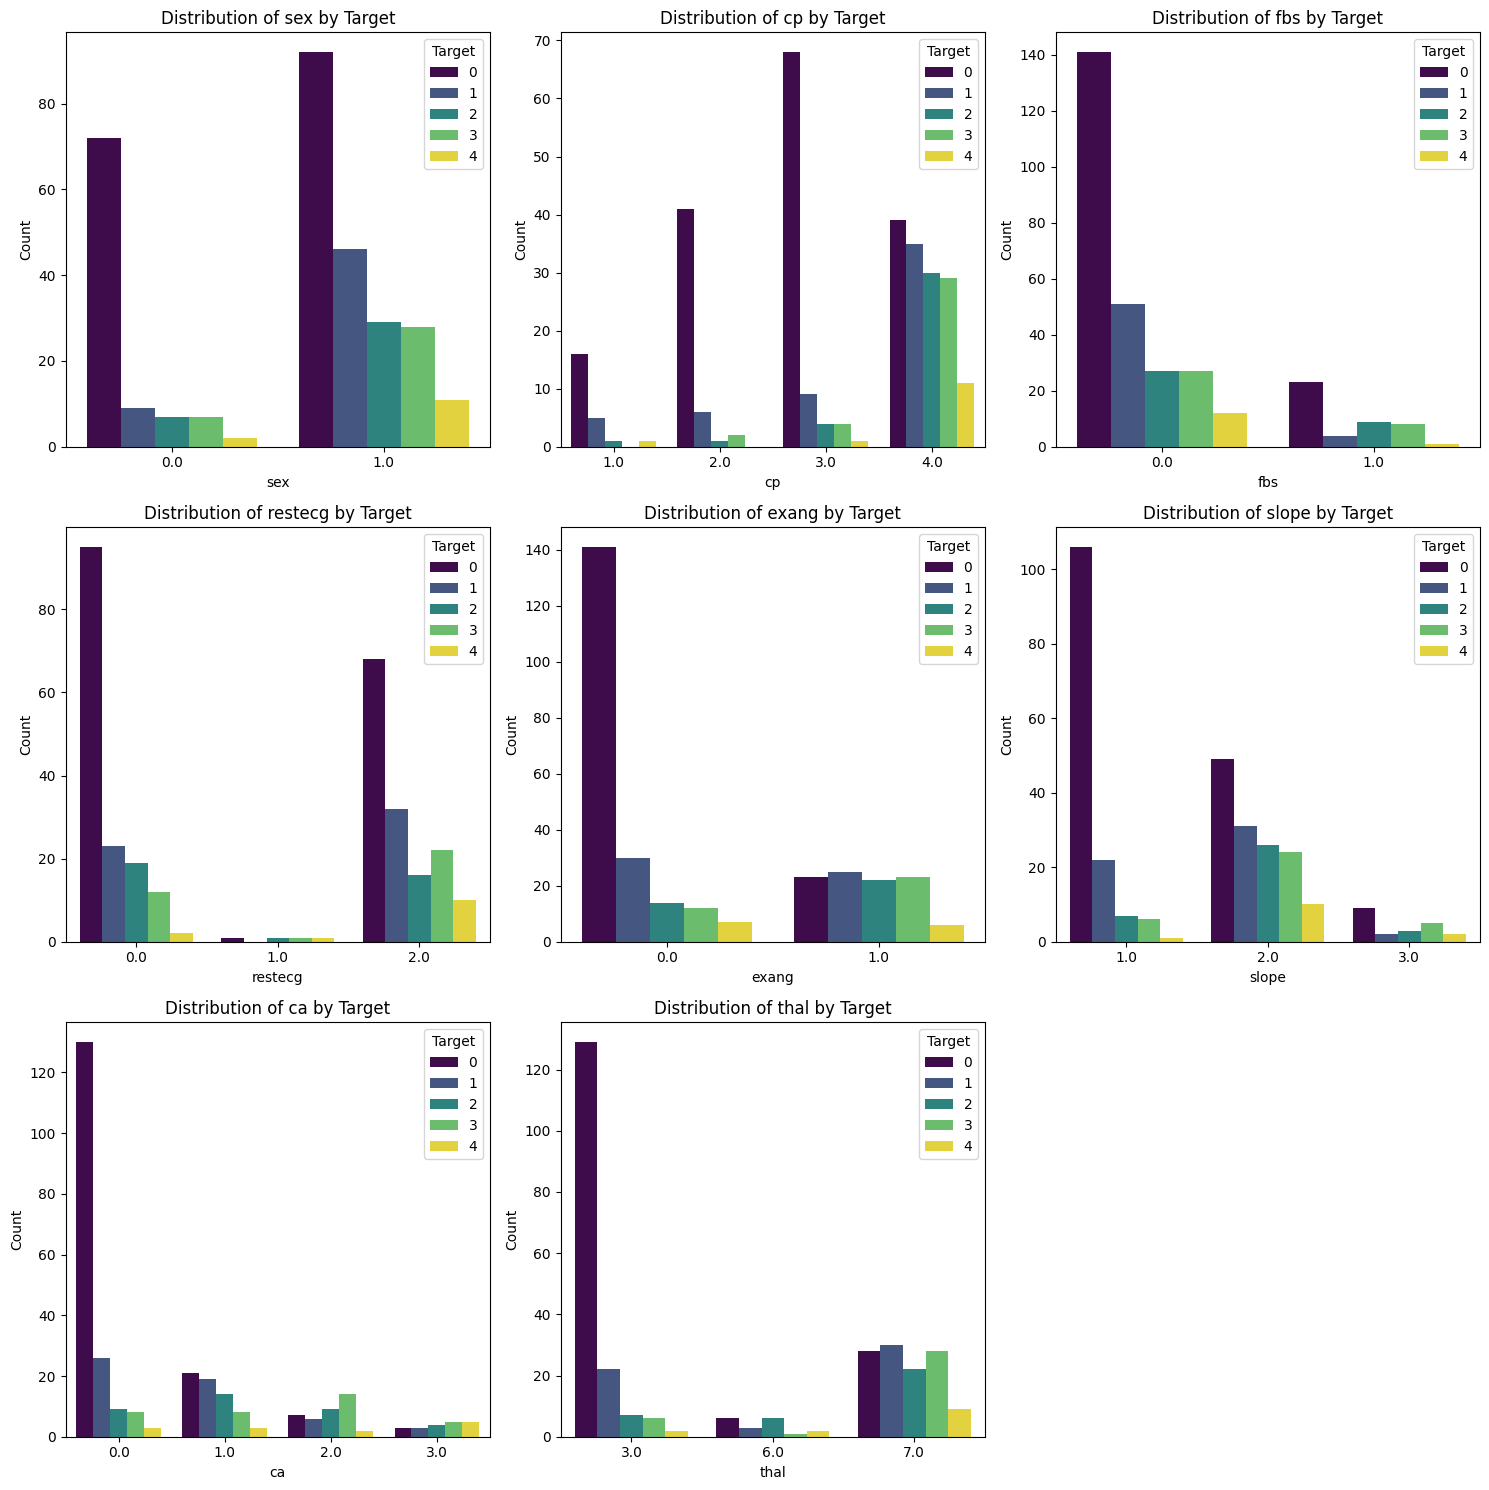

In [124]:
# Select categorical columns (excluding the target variable itself for grouping)
categorical_cols_for_grouping = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

# Determine the number of rows and columns for the subplot grid
n_cols = 3
n_rows = (len(categorical_cols_for_grouping) + n_cols - 1) // n_cols

# Create count plots for categorical features, grouped by the target variable
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 5))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, col in enumerate(categorical_cols_for_grouping):
    # Handle potential NaN values in categorical columns by adding them to the plot
    sns.countplot(data=df, x=col, hue='target', ax=axes[i], palette='viridis')
    axes[i].set_title(f'Distribution of {col} by Target')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].legend(title='Target')


# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Preprocess the data
Clean the data by handling missing values and encoding categorical features.


Identify columns with missing values and apply a strategy to handle them. Then, identify categorical features and apply one-hot encoding, excluding the target variable. Finally, display the first few rows and information of the preprocessed DataFrame.



In [125]:
# 1. Identify columns with missing values
print("Columns with missing values before handling:")
display(df.isnull().sum())

# 2. Decide on a strategy for handling missing values.
# Given the small number of missing values in 'ca' and 'thal', we will drop the rows.
df.dropna(inplace=True)

print("\nColumns with missing values after handling:")
display(df.isnull().sum())

# 3. Identify categorical features that need encoding.
# Based on the data description and EDA, the following columns are considered categorical:
# 'sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal'
# The 'target' variable is also categorical but should not be encoded as it is the target.

categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

# 4. Apply one-hot encoding to the identified categorical features.
df_encoded = pd.get_dummies(df, columns=categorical_features, drop_first=True) # drop_first to avoid multicollinearity

# 5. Display the first few rows and the information of the preprocessed DataFrame to verify the changes.
print("\nFirst 5 rows of the preprocessed DataFrame:")
display(df_encoded.head())

print("\nInformation about the preprocessed DataFrame:")
display(df_encoded.info())

Columns with missing values before handling:


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0



Columns with missing values after handling:


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0



First 5 rows of the preprocessed DataFrame:


,age,trestbps,chol,thalach,oldpeak,target,sex_1.0,cp_2.0,cp_3.0,cp_4.0,...,restecg_1.0,restecg_2.0,exang_1.0,slope_2.0,slope_3.0,ca_1.0,ca_2.0,ca_3.0,thal_6.0,thal_7.0
0,63.0,145.0,233.0,150.0,2.3,0,True,False,False,False,...,False,True,False,False,True,False,False,False,True,False
1,67.0,160.0,286.0,108.0,1.5,2,True,False,False,True,...,False,True,True,True,False,False,False,True,False,False
2,67.0,120.0,229.0,129.0,2.6,1,True,False,False,True,...,False,True,True,True,False,False,True,False,False,True
3,37.0,130.0,250.0,187.0,3.5,0,True,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,41.0,130.0,204.0,172.0,1.4,0,False,True,False,False,...,False,True,False,False,False,False,False,False,False,False



Information about the preprocessed DataFrame:
<class 'pandas.core.frame.DataFrame'>
Index: 297 entries, 0 to 301
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          297 non-null    float64
 1   trestbps     297 non-null    float64
 2   chol         297 non-null    float64
 3   thalach      297 non-null    float64
 4   oldpeak      297 non-null    float64
 5   target       297 non-null    int64  
 6   sex_1.0      297 non-null    bool   
 7   cp_2.0       297 non-null    bool   
 8   cp_3.0       297 non-null    bool   
 9   cp_4.0       297 non-null    bool   
 10  fbs_1.0      297 non-null    bool   
 11  restecg_1.0  297 non-null    bool   
 12  restecg_2.0  297 non-null    bool   
 13  exang_1.0    297 non-null    bool   
 14  slope_2.0    297 non-null    bool   
 15  slope_3.0    297 non-null    bool   
 16  ca_1.0       297 non-null    bool   
 17  ca_2.0       297 non-null    bool   
 18  ca_3.0  

None

## Split the dataset into training and testing sets.


Split the preprocessed data into training and testing sets using train_test_split from sklearn.model_selection.



In [126]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target variable (y)
X = df_encoded.drop('target', axis=1)
y = df_encoded['target']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# Print the shapes of the resulting sets
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (222, 20)
Shape of X_test: (75, 20)
Shape of y_train: (222,)
Shape of y_test: (75,)


## Build and train a classification model
Choose a suitable classification model (e.g., Logistic Regression, RandomForestClassifier, Gradient Boosting) and train it on the training data.


Import the necessary class, instantiate the model, and train it on the training data.



In [127]:
from sklearn.linear_model import LogisticRegression

# Instantiate a Logistic Regression model
# Using default parameters for a start
model = LogisticRegression(max_iter=1000) # Increased max_iter for convergence

# Train the model on the training data
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Evaluate the model
Assess the performance of the trained model using appropriate metrics (e.g., accuracy, precision, recall, F1-score, AUC-ROC) on the testing data.


Import necessary metrics, make predictions on the test set, calculate, and print the performance metrics.



In [128]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Make predictions on the testing data
y_pred = model.predict(X_test)

# Calculate performance metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Calculate AUC-ROC. Need predicted probabilities for this.
# roc_auc_score with 'weighted' average for multi-class
y_pred_proba = model.predict_proba(X_test)
# For multi-class, roc_auc_score with 'weighted' average is calculated based on
# the one-vs-rest (OvR) approach.
auc_roc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted')


# Print the metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (weighted): {precision:.4f}")
print(f"Recall (weighted): {recall:.4f}")
print(f"F1-score (weighted): {f1:.4f}")
print(f"AUC-ROC (weighted OvR): {auc_roc:.4f}")

Accuracy: 0.5600
Precision (weighted): 0.5240
Recall (weighted): 0.5600
F1-score (weighted): 0.5406
AUC-ROC (weighted OvR): 0.8309


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Interpret the model
If possible, interpret the model to understand which features are most important in predicting heart disease.


Check if the trained model has the `coef_` attribute and if so, extract and display the feature importances.



In [129]:
# 1. Check if the trained model has a coef_ attribute.
if hasattr(model, 'coef_'):
    print("The model has a coef_ attribute.")

    # 2. If the coef_ attribute exists, extract the coefficients.
    # For multi-class logistic regression, coef_ is a 2D array (n_classes, n_features).
    # We can look at the absolute mean of coefficients across classes for overall importance.
    coefficients = model.coef_
    feature_names = X.columns

    # Calculate the mean absolute coefficient for each feature across all classes
    mean_abs_coefficients = np.mean(np.abs(coefficients), axis=0)


    # 3. Create a pandas Series that maps the feature names to their corresponding coefficients.
    # Use the mean absolute coefficients for a single measure of importance.
    feature_importances = pd.Series(mean_abs_coefficients, index=feature_names)

    # 4. Sort the coefficients by their absolute values in descending order.
    sorted_feature_importances = feature_importances.sort_values(ascending=False)

    # 5. Print or display the sorted feature importances.
    print("\nSorted Feature Importances (Mean Absolute Coefficient):")
    display(sorted_feature_importances)

else:
    print("The trained model does not have a coef_ attribute. Interpretation of coefficients is not directly possible for this model type.")


The model has a coef_ attribute.

Sorted Feature Importances (Mean Absolute Coefficient):


,0
ca_2.0,0.509447
thal_7.0,0.506321
ca_1.0,0.455132
ca_3.0,0.355008
cp_4.0,0.340201
sex_1.0,0.322417
oldpeak,0.315342
thal_6.0,0.313247
fbs_1.0,0.304606
slope_2.0,0.283818


The previous code failed because the `numpy` library was not imported. Import `numpy` and rerun the code to calculate and display the feature importances.



In [130]:
import numpy as np

# 1. Check if the trained model has a coef_ attribute.
if hasattr(model, 'coef_'):
    print("The model has a coef_ attribute.")

    # 2. If the coef_ attribute exists, extract the coefficients.
    # For multi-class logistic regression, coef_ is a 2D array (n_classes, n_features).
    # We can look at the absolute mean of coefficients across classes for overall importance.
    coefficients = model.coef_
    feature_names = X.columns

    # Calculate the mean absolute coefficient for each feature across all classes
    mean_abs_coefficients = np.mean(np.abs(coefficients), axis=0)


    # 3. Create a pandas Series that maps the feature names to their corresponding coefficients.
    # Use the mean absolute coefficients for a single measure of importance.
    feature_importances = pd.Series(mean_abs_coefficients, index=feature_names)

    # 4. Sort the coefficients by their absolute values in descending order.
    sorted_feature_importances = feature_importances.sort_values(ascending=False)

    # 5. Print or display the sorted feature importances.
    print("\nSorted Feature Importances (Mean Absolute Coefficient):")
    display(sorted_feature_importances)

else:
    print("The trained model does not have a coef_ attribute. Interpretation of coefficients is not directly possible for this model type.")

The model has a coef_ attribute.

Sorted Feature Importances (Mean Absolute Coefficient):


,0
ca_2.0,0.509447
thal_7.0,0.506321
ca_1.0,0.455132
ca_3.0,0.355008
cp_4.0,0.340201
sex_1.0,0.322417
oldpeak,0.315342
thal_6.0,0.313247
fbs_1.0,0.304606
slope_2.0,0.283818


## Compare Results

Compare the evaluation metrics of the model trained on the balanced data with the baseline model to assess the impact of handling class imbalance.

In [131]:
# Display the metrics from the baseline model (trained on imbalanced data)
print("Evaluation Metrics - Baseline Model (Imbalanced Data):")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (weighted): {precision:.4f}")
print(f"Recall (weighted): {recall:.4f}")
print(f"F1-score (weighted): {f1:.4f}")
print(f"AUC-ROC (weighted OvR): {auc_roc:.4f}")

print("-" * 30)

# Display the metrics from the model trained on resampled data
print("Evaluation Metrics - Model Trained on Resampled Data (SMOTE):")
print(f"Accuracy: {accuracy_resampled:.4f}")
print(f"Precision (weighted): {precision_resampled_weighted:.4f}")
print(f"Recall (weighted): {recall_resampled_weighted:.4f}")
print(f"F1-score (weighted): {f1_resampled_weighted:.4f}")
if not np.isnan(auc_roc_resampled):
    print(f"AUC-ROC (weighted OvR): {auc_roc_resampled:.4f}")
else:
    print("AUC-ROC (weighted OvR): Not applicable (less than 2 common classes in test set)")


print("\nClassification Report (Baseline Model):")
print(classification_report(y_test, y_pred, zero_division=0))

print("\nClassification Report (Resampled Model):")
print(classification_report(y_test, y_pred_resampled, zero_division=0))

Evaluation Metrics - Baseline Model (Imbalanced Data):
Accuracy: 0.5600
Precision (weighted): 0.5240
Recall (weighted): 0.5600
F1-score (weighted): 0.5406
AUC-ROC (weighted OvR): 0.8309
------------------------------
Evaluation Metrics - Model Trained on Resampled Data (SMOTE):
Accuracy: 0.5733
Precision (weighted): 0.5588
Recall (weighted): 0.5733
F1-score (weighted): 0.5659
AUC-ROC (weighted OvR): 0.8320

Classification Report (Baseline Model):
              precision    recall  f1-score   support

           0       0.84      0.93      0.88        40
           1       0.33      0.29      0.31        14
           2       0.00      0.00      0.00         9
           3       0.11      0.11      0.11         9
           4       0.00      0.00      0.00         3

    accuracy                           0.56        75
   macro avg       0.26      0.26      0.26        75
weighted avg       0.52      0.56      0.54        75


Classification Report (Resampled Model):
              prec

## Summarize the findings and the effectiveness of addressing class imbalance.

Address the class imbalance in the target variable using techniques like oversampling, undersampling, or using evaluation metrics more robust to imbalance (e.g., confusion matrix, per-class precision/recall).

## Examine class distribution
Visualize or print the distribution of the target variable in the training set to confirm the class imbalance.


Calculate and print the value counts of the target variable in the training set, then visualize the distribution using a count plot to confirm class imbalance.



Distribution of Target Variable in Training Set:


,count
target,
0,120
1,40
2,26
3,26
4,10


/tmp/ipython-input-680720994.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, palette='viridis')


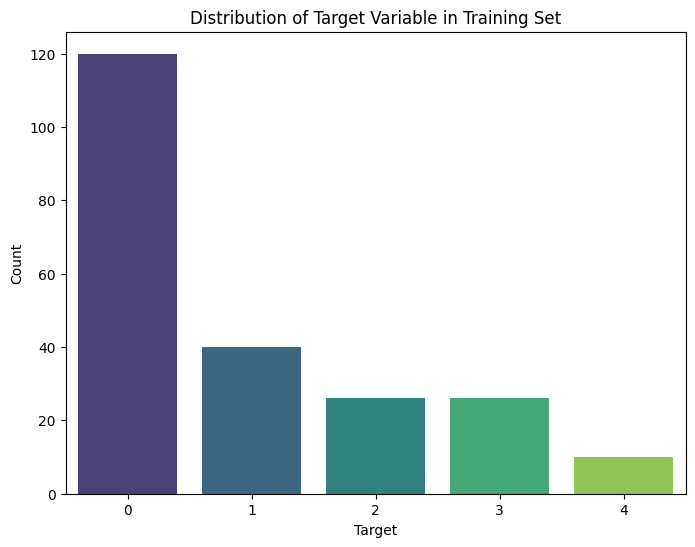

In [132]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate the value counts of the y_train Series
target_distribution_train = y_train.value_counts()

# 2. Print the class distribution
print("Distribution of Target Variable in Training Set:")
display(target_distribution_train)

# 3. Create a count plot of y_train
plt.figure(figsize=(8, 6))
sns.countplot(x=y_train, palette='viridis')
plt.title('Distribution of Target Variable in Training Set')
plt.xlabel('Target')
plt.ylabel('Count')

# 4. Display the plot
plt.show()

## Apply smote
Use SMOTE to oversample the minority classes in the training data to create a more balanced dataset for training.


Apply SMOTE to the training data to address the class imbalance and then display the shapes of the original and resampled data and the distribution of the resampled target variable.



In [133]:
from imblearn.over_sampling import SMOTE

# Instantiate a SMOTE object
# random_state for reproducibility
smote = SMOTE(random_state=42)

# Apply SMOTE to the training data
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Print the shape of the original and resampled training data
print("Shape of original training data:", X_train.shape)
print("Shape of resampled training data:", X_train_resampled.shape)

# Print the distribution of the target variable in the resampled training set
print("\nDistribution of Target Variable in Resampled Training Set:")
display(y_train_resampled.value_counts())

Shape of original training data: (222, 20)
Shape of resampled training data: (600, 20)

Distribution of Target Variable in Resampled Training Set:


,count
target,
0,120
1,120
2,120
4,120
3,120


## Retrain the model
Train a new classification model (or retrain the existing one) on the SMOTE-augmented training data.


Instantiate and train a Logistic Regression model on the SMOTE-augmented training data.



In [134]:
# 1. Instantiate a new Logistic Regression model
# Using default parameters for a start and increased max_iter for convergence
model_resampled = LogisticRegression(max_iter=1000)

# 2. Train the model on the resampled training data
model_resampled.fit(X_train_resampled, y_train_resampled)

# 3. Print a confirmation message
print("Logistic Regression model trained successfully on resampled data.")

Logistic Regression model trained successfully on resampled data.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Evaluate the model
Evaluate the performance of the retrained model on the original, untouched testing data using appropriate metrics, paying attention to per-class performance.


Make predictions on the test set and calculate various evaluation metrics including per-class precision, recall, and f1-score to assess the performance of the model trained on resampled data.



In [135]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

# Make predictions on the original testing data using the model trained on resampled data
y_pred_resampled = model_resampled.predict(X_test)

# Calculate accuracy
accuracy_resampled = accuracy_score(y_test, y_pred_resampled)
print(f"Accuracy (Resampled Model): {accuracy_resampled:.4f}")

# Calculate weighted average metrics
precision_resampled_weighted = precision_score(y_test, y_pred_resampled, average='weighted', zero_division=0)
recall_resampled_weighted = recall_score(y_test, y_pred_resampled, average='weighted', zero_division=0)
f1_resampled_weighted = f1_score(y_test, y_pred_resampled, average='weighted', zero_division=0)

print(f"\nPrecision (weighted, Resampled Model): {precision_resampled_weighted:.4f}")
print(f"Recall (weighted, Resampled Model): {recall_resampled_weighted:.4f}")
print(f"F1-score (weighted, Resampled Model): {f1_resampled_weighted:.4f}")

# Calculate per-class metrics
print("\nClassification Report (Resampled Model):")
print(classification_report(y_test, y_pred_resampled, zero_division=0))

# Calculate AUC-ROC (weighted OvR)
# Need predicted probabilities for this.
y_pred_proba_resampled = model_resampled.predict_proba(X_test)
# Handle the case where y_test might have classes not present in y_train_resampled
# This can happen with small test sets and original class imbalance
# Ensure all classes from y_test are considered in the roc_auc_score calculation
classes_in_y_test = np.unique(y_test)
classes_in_y_train_resampled = np.unique(y_train_resampled)

# Filter y_test and y_pred_proba_resampled to include only classes present in both
common_classes = np.intersect1d(classes_in_y_test, classes_in_y_train_resampled)

# If the number of common classes is less than 2, AUC-ROC cannot be calculated meaningfully
if len(common_classes) < 2:
    print("\nAUC-ROC cannot be calculated meaningfully as there are less than 2 common classes between test set and resampled training set.")
    auc_roc_resampled = np.nan # Assign NaN as AUC-ROC is not applicable
else:
    # Determine the column indices in y_pred_proba_resampled corresponding to common_classes
    class_indices = [np.where(model_resampled.classes_ == c)[0][0] for c in common_classes]
    y_test_filtered = y_test[y_test.isin(common_classes)]
    y_pred_proba_resampled_filtered = y_pred_proba_resampled[y_test.isin(common_classes)][:, class_indices]

    # Map filtered y_test to a range starting from 0 for roc_auc_score
    class_mapping = {cls: i for i, cls in enumerate(common_classes)}
    y_test_mapped = y_test_filtered.map(class_mapping)


    auc_roc_resampled = roc_auc_score(y_test_mapped, y_pred_proba_resampled_filtered, multi_class='ovr', average='weighted')
    print(f"AUC-ROC (weighted OvR, Resampled Model): {auc_roc_resampled:.4f}")


Accuracy (Resampled Model): 0.5733

Precision (weighted, Resampled Model): 0.5588
Recall (weighted, Resampled Model): 0.5733
F1-score (weighted, Resampled Model): 0.5659

Classification Report (Resampled Model):
              precision    recall  f1-score   support

           0       0.88      0.90      0.89        40
           1       0.33      0.36      0.34        14
           2       0.11      0.11      0.11         9
           3       0.12      0.11      0.12         9
           4       0.00      0.00      0.00         3

    accuracy                           0.57        75
   macro avg       0.29      0.30      0.29        75
weighted avg       0.56      0.57      0.57        75

AUC-ROC (weighted OvR, Resampled Model): 0.8320
